In [1]:
import tensorflow as tf

print(tf.__version__)

2.20.0


In [2]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


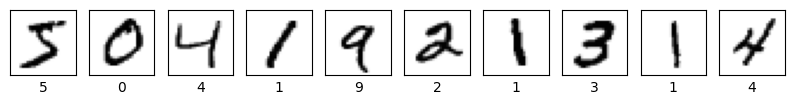

In [4]:
import matplotlib.pyplot as plt

x_train, x_test = x_train / 255.0, x_test / 255.0

plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

In [5]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)
print(f'\nTest accuracy: {test_acc}')

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6825 - loss: 1.2812 - val_accuracy: 0.8645 - val_loss: 0.6070
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8434 - loss: 0.5748 - val_accuracy: 0.9042 - val_loss: 0.3860
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8753 - loss: 0.4463 - val_accuracy: 0.9190 - val_loss: 0.3141
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8878 - loss: 0.3908 - val_accuracy: 0.9248 - val_loss: 0.2791
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8965 - loss: 0.3573 - val_accuracy: 0.9283 - val_loss: 0.2599
313/313 - 1s - 2ms/step - accuracy: 0.9122 - loss: 0.3029

Test accuracy: 0.9121999740600586


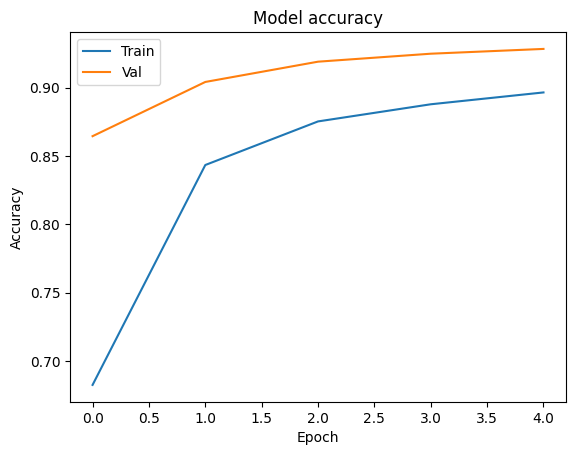

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


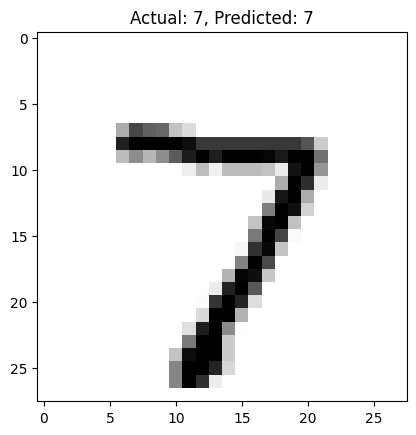

In [7]:
import numpy as np

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

sample_idx = 0
prediction = model.predict(x_test[sample_idx:sample_idx+1])
predicted_label = np.argmax(prediction)

plt.imshow(x_test[sample_idx], cmap=plt.cm.binary)
plt.title(f'Actual: {y_test[sample_idx]}, Predicted: {predicted_label}')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


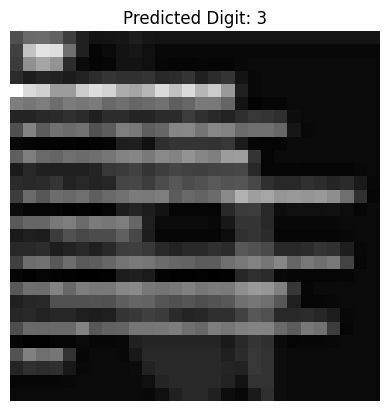

In [8]:
from PIL import Image
import numpy as np

img_path = '/content/Screenshot 2026-06-17 191817.png'


img = Image.open(img_path).convert('L')
img = img.resize((28, 28))


img_array = np.array(img)
if np.mean(img_array) > 127:
    img_array = 255 - img_array


img_array = img_array / 255.0
img_input = img_array.reshape(1, 28, 28)

custom_pred = model.predict(img_input)
custom_label = np.argmax(custom_pred)


plt.imshow(img_array, cmap='gray')
plt.title(f'Predicted Digit: {custom_label}')
plt.axis('off')
plt.show()

### Improving Model Accuracy with a CNN
To go beyond 91%, we can use a Convolutional Neural Network (CNN) architecture, which is the standard for image classification tasks.

In [9]:
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)
cnn_model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

cnn_history = cnn_model.fit(x_train_cnn, y_train, epochs=10, validation_split=0.1)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_cnn, y_test, verbose=2)
print(f'\nImproved CNN Test accuracy: {cnn_test_acc}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 31ms/step - accuracy: 0.6810 - loss: 0.9346 - val_accuracy: 0.9133 - val_loss: 0.2843
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.8950 - loss: 0.3420 - val_accuracy: 0.9500 - val_loss: 0.1807
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9217 - loss: 0.2546 - val_accuracy: 0.9608 - val_loss: 0.1434
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9362 - loss: 0.2069 - val_accuracy: 0.9695 - val_loss: 0.1116
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9464 - loss: 0.1739 - val_accuracy: 0.9697 - val_loss: 0.1033
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9534 - loss: 0.1513 - val_accuracy: 0.9735 - val_loss: 0.0906
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 80s 30ms/step - accuracy: 0.9604 - loss: 0.1323 - val_accuracy: 0.9757 - val_loss: 0.0853
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.9628 -

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


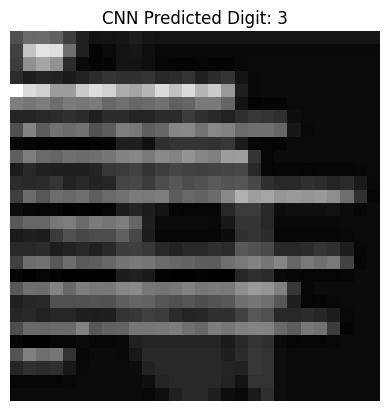

In [10]:

img_input_cnn = img_array.reshape(1, 28, 28, 1)
cnn_custom_pred = cnn_model.predict(img_input_cnn)
cnn_custom_label = np.argmax(cnn_custom_pred)

plt.imshow(img_array, cmap='gray')
plt.title(f'CNN Predicted Digit: {cnn_custom_label}')
plt.axis('off')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step


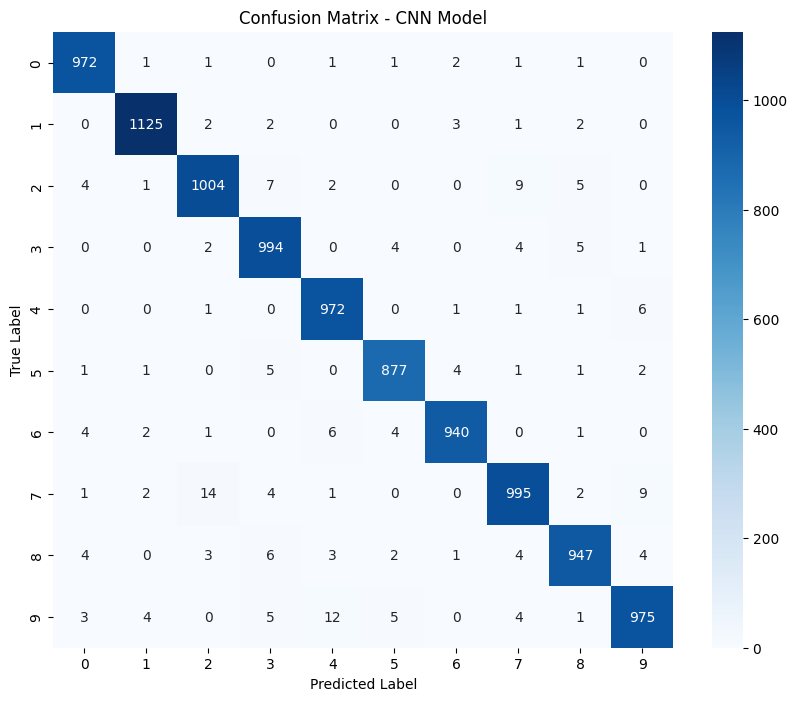

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred_cnn = cnn_model.predict(x_test_cnn)
y_pred_labels = np.argmax(y_pred_cnn, axis=1)

cm = confusion_matrix(y_test, y_pred_labels)


plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - CNN Model')
plt.show()

Total misclassified images: 199 out of 10,000


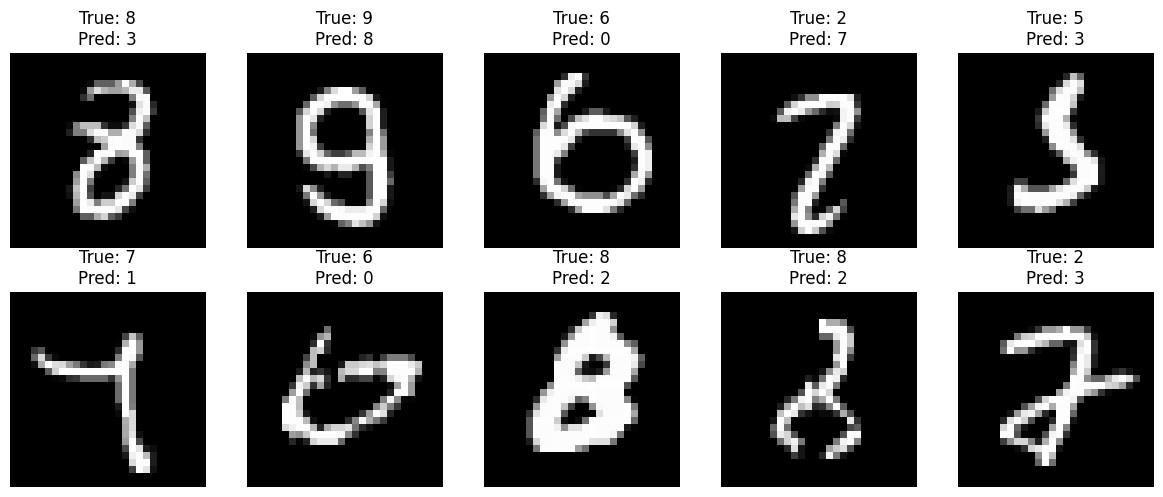

In [12]:

misclassified_idx = np.where(y_pred_labels != y_test)[0]

print(f"Total misclassified images: {len(misclassified_idx)} out of 10,000")

plt.figure(figsize=(12, 5))
for i, idx in enumerate(misclassified_idx[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"True: {y_test[idx]}\nPred: {y_pred_labels[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Aiming for 99% Accuracy
To reach the 99% threshold, we will use:
1. **Batch Normalization**: To speed up training and provide regularization.
2. **More Filters**: Increasing the depth of the network.
3. **Data Augmentation**: Artificially expanding the dataset with rotations and shifts.

In [14]:
cnn_model.save("mnist_cnn_model.keras")